In [1]:
import os
import glob
import shapeworks as sw
import pytorch3d
import numpy as np
import torch

def get_particles(model_path):
    f = open(model_path, "r")
    data = []
    for line in f.readlines():
        points = line.split()
        points = [float(i) for i in points]
        data.append(points)
    return(data)

In [2]:
DEVICE = "cpu"
from pytorch3d.loss import chamfer_distance

def get_particles(model_path):
    f = open(model_path, "r")
    data = []
    for line in f.readlines():
        points = line.split()
        points = [float(i) for i in points]
        data.append(points)
    return(data)

def get_specificity_cd(spec_dir, particle_dir, remove=True):
	xml_files = sorted(glob.glob(spec_dir+'/*.xml'))
	generated_particle_files = sorted(glob.glob(spec_dir+'/*.particles'))
	# preds, gt = get_particles(particle_dir)
	generated_particles, closest_gts = [], []
	for i in range(len(xml_files)):
		with open(xml_files[i]) as f:
			first_line = f.readline().strip('\n')
		closest_file = os.path.basename(first_line)
		# print(closest_file, generated_particle_files[i])
		generated_particles.append(np.loadtxt(generated_particle_files[i]))
		closest_gts.append(np.loadtxt(particle_dir+'/'+closest_file))
	generated_particles = torch.tensor(np.array(generated_particles)).float()
	closest_gts = torch.tensor(np.array(closest_gts)).float()
	print(generated_particles.shape, closest_gts.shape)
	cd_l2, _ = chamfer_distance(generated_particles, closest_gts, norm=2)
	if remove:
		for file in xml_files:
			os.remove(file)
		for file in generated_particle_files:
			os.remove(file)
	return cd_l2.cpu().numpy().mean()

def ComputeGeneralization(particle_dir, unseen_particle_dir, num_modes):
	point_matrix, gt = get_particles(particle_dir)
	unseen_point_matrix, unseen_gt = get_particles(unseen_particle_dir)
	point_embedder = PCA_Embbeder(np.array(point_matrix), num_dim=num_modes)
	embedded_matrix = point_embedder.run_PCA()
	unseen_embedded_matrix = point_embedder.getEmbeddedMatrix(unseen_point_matrix)
	unseen_reconstructed = point_embedder.project(unseen_embedded_matrix)
	norm = np.linalg.norm(unseen_point_matrix-unseen_reconstructed, axis=-1)
	cd_l2, _ = pytorch3d.loss.chamfer_distance(torch.FloatTensor(unseen_reconstructed).to(DEVICE), torch.FloatTensor(unseen_gt).to(DEVICE), norm=2)
	return np.mean(norm), cd_l2.cpu().numpy()

def get_particle_files(model_dir):
    world_particle_list = []
    local_particle_list = []
    for file in os.listdir(model_dir):
        if "meanshape" in file:
            continue
        if "local" in file:
            local_particle_list.append(os.path.join(model_dir, file))
        if "world" in file:
            world_particle_list.append(os.path.join(model_dir, file))

    world_particle_list = sorted(world_particle_list)
    local_particle_list = sorted(local_particle_list)
    return local_particle_list


# PCA analysis
def PCA_analysis(particle_dir, unseen_particle_dir, out_dir):
	if not os.path.exists(out_dir):
		os.makedirs(out_dir)
	particle_files = get_particle_files(particle_dir)
	particleSystem = sw.ParticleSystem(particle_files)

	allCompactness = sw.ShapeEvaluation.ComputeFullCompactness(particleSystem=particleSystem)	
	print(allCompactness)
	compact_modes = 0

	# nSpecificity = sw.ShapeEvaluation.ComputeSpecificity(particleSystem=particleSystem, nModes=len(allCompactness), saveTo=out_dir)
	# # spec_cd = get_specificity_cd(out_dir, particle_dir)
	# print("Specificity CD", spec_cd)
	
	# gen_l2, gen_cd = ComputeGeneralization(particle_dir, unseen_particle_dir, len(allCompactness))
	# print("Generalization CD", gen_cd)

In [3]:
from data_augmentation import Gaussian_Sampler


/home/asmak/miniconda3/envs/shape_dev/lib/python3.12/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,


In [4]:
from DataAugmentationUtils import Embedder, Utils
import subprocess
from pytorch3d.loss import chamfer_distance
from data_augmentation import Gaussian_Sampler

def get_particles(model_path):
    f = open(model_path, "r")
    data = []
    for line in f.readlines():
        points = line.split()
        points = [float(i) for i in points]
        data.append(points)
    return(data)

def get_particle_files(model_dir):
    world_particle_list = []
    local_particle_list = []
    for file in os.listdir(model_dir):
        if "meanshape" in file:
            continue
        if "local" in file:
            local_particle_list.append(os.path.join(model_dir, file))
        if "world" in file:
            world_particle_list.append(os.path.join(model_dir, file))

    world_particle_list = sorted(world_particle_list)
    local_particle_list = sorted(local_particle_list)
    return local_particle_list

def GetGeneralization(dt_path, particle_path, num_modes):
    all_particles = get_particle_files(particle_path)
    all_dts = sorted(glob.glob(os.path.join(dt_path, "*.vtk")))
    template_mesh = all_dts[0]
    template_particles = all_particles[0]
    point_matrix = []
    
    point_matrix = Utils.create_data_matrix(all_particles)    
    point_embedder = Embedder.PCA_Embbeder(np.array(point_matrix), num_dim=num_modes)
    pca_scores = point_embedder.PCA_scores
    
    all_c2s = []
    for i in range(len(all_particles)):
        current_particles = point_embedder.project(pca_scores[i])
        np.savetxt(os.path.join("tmp/p.particles"), current_particles)
        execCommand = ["shapeworks", 
                    "warp-mesh", "--reference_mesh", template_mesh,
                    "--reference_points", template_particles,
                    "--target_points", "tmp/p.particles" ]
        subprocess.check_call(execCommand)
        rMesh = sw.Mesh("tmp/p.vtk")
        gtMesh = sw.Mesh(all_dts[i])
        rMesh_verts = torch.tensor(rMesh.points()).float().unsqueeze(0)
        gtMesh_verts = torch.tensor(gtMesh.points()).float().unsqueeze(0)
        cd_l2, _ = chamfer_distance(gtMesh_verts, rMesh_verts, norm=2)
        all_c2s.append(cd_l2.squeeze().item())
    return np.mean(np.array(all_c2s))
        

def convertToMesh(dt_path):
    save_path = dt_path.replace("distance_transforms", "mesh")
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    all_dts = sorted(glob.glob(os.path.join(dt_path, "*.nrrd")))
    for i in range(len(all_dts)):
        dt = sw.Image(all_dts[i])
        dt.toMesh(0).remesh(10000, 1.0).write(all_dts[i].replace("distance_transforms", "mesh").replace(".nrrd", ".vtk"))
    return save_path, len(all_dts)

def GetSpecificity(dt_path, particle_path, num_modes):
    all_particles = get_particle_files(particle_path)
    particleSystem = sw.ParticleSystem(all_particles)

    all_dts = sorted(glob.glob(os.path.join(dt_path, "*.vtk")))
    template_mesh = all_dts[0]
    template_particles = all_particles[0]
    
    point_matrix = Utils.create_data_matrix(all_particles)    
    point_embedder = Embedder.PCA_Embbeder(np.array(point_matrix), num_dim=num_modes)
    pca_scores = point_embedder.PCA_scores
    
    pca_distribution = Gaussian_Sampler()
    pca_distribution.fit(pca_scores)

    
    all_c2s = []
    for i in range(10):
        sampled_pca, closest_index = pca_distribution.sample()
        sampled_points = point_embedder.project(sampled_pca)
        
        np.savetxt(os.path.join("tmp/p.particles"), sampled_points)
        execCommand = ["shapeworks", 
                    "warp-mesh", "--reference_mesh", template_mesh,
                    "--reference_points", template_particles,
                    "--target_points", "tmp/p.particles" ]
        subprocess.check_call(execCommand)
        rMesh = sw.Mesh("tmp/p.vtk")
        gtMesh = sw.Mesh(all_dts[closest_index])
        rMesh_verts = torch.tensor(rMesh.points()).float().unsqueeze(0)
        gtMesh_verts = torch.tensor(gtMesh.points()).float().unsqueeze(0)
        cd_l2, _ = chamfer_distance(gtMesh_verts, rMesh_verts, norm=2)
        all_c2s.append(cd_l2.squeeze().item())

    
    return np.mean(np.array(all_c2s))
    
def distance_subspace(gt_particle_path, particle_path, num_modes):
    
    all_particles_gt = get_particle_files(gt_particle_path)    
    point_matrix_gt = Utils.create_data_matrix(all_particles_gt)    
    point_embedder_gt = Embedder.PCA_Embbeder(np.array(point_matrix_gt), num_dim=num_modes)
    pca_scores_gt = point_embedder_gt.PCA_scores
    
    all_particles = get_particle_files(particle_path)    
    point_matrix = Utils.create_data_matrix(all_particles)    
    point_embedder = Embedder.PCA_Embbeder(np.array(point_matrix), num_dim=num_modes)
    pca_scores = point_embedder.PCA_scores
    
    subspace_A = pca_scores_gt.T
    subspace_B = pca_scores.T
    
    U, s, Vt = np.linalg.svd(subspace_A.T @ subspace_B)
    cosines = np.clip(s, -1.0, 1.0)
    principal_angles = np.arccos(cosines)
    distance = np.sqrt(1 - np.sum(np.cos(principal_angles) ** 2))

    return distance
    
    


In [5]:
import matplotlib.pyplot as plt
gt = np.load("femur/gt/groomed_test/stats_new.npz")

modes = np.arange(len(gt["gen"])) + 1


plt.plot(modes, gt["gen"], "r-", label='GT')

plt.xlabel('Modes')
plt.ylabel('Generalization')
# plt.xticks(modes)
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'femur/gt/groomed_test/stats_new.npz'

In [6]:
# KEY KEY KEY
import numpy as np

# gt = np.load("femur/gt/groomed_test/stats_new.npz")
# bcp = np.load("femur/bcp/groomed_test/stats_new.npz")
# mt_uc = np.load("femur/mt_uc/groomed_test/stats_new.npz")
# mt = np.load("femur/mt/groomed_test/stats_new.npz")
# vnet = np.load("femur/vnet/groomed_test/stats_new.npz")
# an = np.load("femur/an/groomed_test/stats_new.npz")
# em = np.load("femur/em/groomed_test/stats_new.npz")
# rd = np.load("femur/rd/groomed_test/stats_new.npz")
# urpc = np.load("femur/urpc/groomed_test/stats_new.npz")
# sam1 = np.load("femur/sam1/groomed_test/stats_new.npz")
# sam10 = np.load("femur/sam10/groomed_test/stats_new.npz")

# setting I
gt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/groomed_test/stats_new.npz")
caml = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.CAML.testing/groomed_test/stats_new.npz")
desco = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.DeSCO.testing/groomed_test/stats_new.npz")
dtc = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.DTC.testing/groomed_test/stats_new.npz")
mcf = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.MCF.testing/groomed_test/stats_new.npz")
sassnet = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.SASSnet.testing/groomed_test/stats_new.npz")


FileNotFoundError: [Errno 2] No such file or directory: '/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/groomed_test/stats_new.npz'

Generalization:

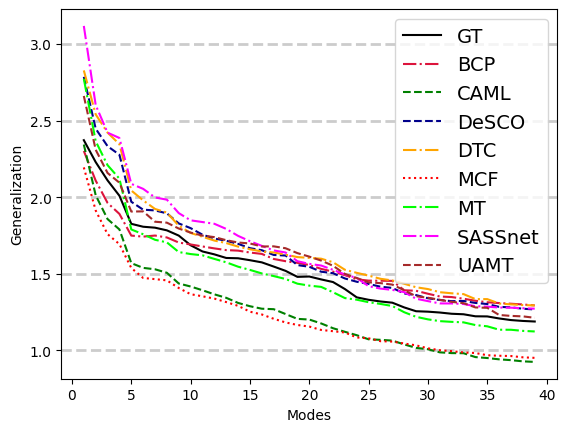

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# namic 20%
gt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/groomed_test/stats_new.npz")
bcp = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.BCP.testing/groomed_test/stats_new.npz")
caml = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.CAML.testing/groomed_test/stats_new.npz")
desco = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.DeSCO.testing/groomed_test/stats_new.npz")
dtc = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.DTC.testing/groomed_test/stats_new.npz")
mcf = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.MCF.testing/groomed_test/stats_new.npz")
mt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.MT.testing/groomed_test/stats_new.npz")
sassnet = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.SASSnet.testing/groomed_test/stats_new.npz")
uamt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.UAMT.testing/groomed_test/stats_new.npz")

# namic 40%
# gt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/groomed_test/stats_new.npz")
# bcp = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.BCP.testing/groomed_test/stats_new.npz")
# caml = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.CAML.testing/groomed_test/stats_new.npz")
# desco = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.DeSCO.testing/groomed_test/stats_new.npz")
# dtc = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.DTC.testing/groomed_test/stats_new.npz")
# mcf = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.MCF.testing/groomed_test/stats_new.npz")
# mt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.MT.testing/groomed_test/stats_new.npz")
# sassnet = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.SASSnet.testing/groomed_test/stats_new.npz")
# uamt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.UAMT.testing/groomed_test/stats_new.npz")

# femur 20%
# gt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/groomed_test/stats_new.npz")
# bcp = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.BCP.testing/groomed_test/stats_new.npz")
# caml = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.CAML.testing/groomed_test/stats_new.npz")
# desco = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.DeSCO.testing/groomed_test/stats_new.npz")
# dtc = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.DTC.testing/groomed_test/stats_new.npz")
# mcf = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.MCF.testing/groomed_test/stats_new.npz")
# mt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.MT.testing/groomed_test/stats_new.npz")
# sassnet = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.SASSnet.testing/groomed_test/stats_new.npz")
# uamt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.UAMT.testing/groomed_test/stats_new.npz")


# femur 40%
# gt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/groomed_test/stats_new.npz")
# bcp = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.BCP.testing/groomed_test/stats_new.npz")
# caml = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.CAML.testing/groomed_test/stats_new.npz")
# desco = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.DeSCO.testing/groomed_test/stats_new.npz")
# dtc = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.DTC.testing/groomed_test/stats_new.npz")
# mcf = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.MCF.testing/groomed_test/stats_new.npz")
# mt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.MT.testing/groomed_test/stats_new.npz")
# sassnet = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.SASSnet.testing/groomed_test/stats_new.npz")
# uamt = np.load("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.UAMT.testing/groomed_test/stats_new.npz")

modes = np.arange(len(gt["gen"])) + 1

# Setting I
plt.plot(modes, gt["gen"], "black", label='GT')
plt.plot(modes, bcp["gen"], "crimson",label='BCP',linestyle='-.')
plt.plot(modes, caml["gen"], "green",label='CAML',linestyle='--')
plt.plot(modes, desco["gen"], "darkblue",label='DeSCO',linestyle='--')
plt.plot(modes, dtc["gen"], "orange",label='DTC',linestyle='-.')
plt.plot(modes, mcf["gen"], "red",label='MCF',linestyle=':')
plt.plot(modes, mt["gen"], "lime",label='MT',linestyle='-.')
plt.plot(modes, sassnet["gen"], color="magenta",label='SASSnet',linestyle='-.')
plt.plot(modes, uamt["gen"], "brown",label='UAMT',linestyle='--')

plt.xlabel('Modes')
plt.ylabel('Generalization')
# plt.xticks(modes)
plt.legend(fontsize=14)
# plt.legend(fontsize=14, bbox_to_anchor=(1, 1))  # move legend to the right outside the plot
# plt.tight_layout() 

plt.grid(axis='y',color='black', linestyle='--', linewidth=2,alpha=0.2)

plt.show()

Grassmanian:

The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0000000000000002
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 0.9999999999999999
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being retained : 8
Variablity preserved: 1.0
The PCA modes of particles being r

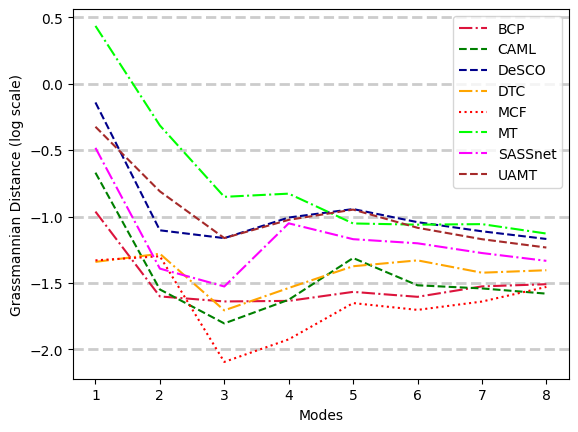

In [26]:
# bcp_sd = distance_subspace("femur/gt/shape_models_1024/la_particles", "femur/bcp/shape_models_1024/la_particles")
# mt_uc_sd = distance_subspace("femur/gt/shape_models_1024/la_particles", "femur/mt_uc/shape_models_1024/la_particles")
# mt_sd = distance_subspace("femur/gt/shape_models_1024/la_particles", "femur/mt/shape_models_1024/la_particles")
# vnet_sd = distance_subspace("femur/gt/shape_models_1024/la_particles", "femur/vnet/shape_models_1024/la_particles")

# namic 20%
# caml_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.CAML.testing/shape_models_1024_fd/la_particles")

# desco_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                              "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.DeSCO.testing/shape_models_1024_fd/la_particles")

# dtc_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.DTC.testing/shape_models_1024_fd/la_particles")

# mcf_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.MCF.testing/shape_models_1024_fd/la_particles")

# sassnet_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.SASSnet.testing/shape_models_1024_fd/la_particles")

# bcp_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.BCP.testing/shape_models_1024_fd/la_particles")

# mt_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                           "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.MT.testing/shape_models_1024_fd/la_particles")

# uamt_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/20_percent_gt/2SSM_gt.training.UAMT.testing/shape_models_1024_fd/la_particles")


# namic 40%
# caml_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.CAML.testing/shape_models_1024_fd/la_particles")

# desco_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                              "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.DeSCO.testing/shape_models_1024_fd/la_particles")

# dtc_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.DTC.testing/shape_models_1024_fd/la_particles")

# mcf_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.MCF.testing/shape_models_1024_fd/la_particles")

# sassnet_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.SASSnet.testing/shape_models_1024_fd/la_particles")

# bcp_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.BCP.testing/shape_models_1024_fd/la_particles")

# mt_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                           "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.MT.testing/shape_models_1024_fd/la_particles")

# uamt_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/namic/40_percent_gt/2SSM_gt.training.UAMT.testing/shape_models_1024_fd/la_particles")

# femur 20%
# caml_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.CAML.testing/shape_models_1024_fd/la_particles")

# desco_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                              "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.DeSCO.testing/shape_models_1024_fd/la_particles")

# dtc_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.DTC.testing/shape_models_1024_fd/la_particles")

# mcf_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.MCF.testing/shape_models_1024_fd/la_particles")

# sassnet_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.SASSnet.testing/shape_models_1024_fd/la_particles")

# bcp_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.BCP.testing/shape_models_1024_fd/la_particles")

# mt_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                           "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.MT.testing/shape_models_1024_fd/la_particles")

# uamt_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
#                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/20_percent_gt/2SSM_gt.training.UAMT.testing/shape_models_1024_fd/la_particles")


# femur 40%
caml_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.CAML.testing/shape_models_1024_fd/la_particles")

desco_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
                             "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.DeSCO.testing/shape_models_1024_fd/la_particles")

dtc_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
                           "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.DTC.testing/shape_models_1024_fd/la_particles")

mcf_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
                           "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.MCF.testing/shape_models_1024_fd/la_particles")

sassnet_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.SASSnet.testing/shape_models_1024_fd/la_particles")

bcp_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
                           "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.BCP.testing/shape_models_1024_fd/la_particles")

mt_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
                          "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.MT.testing/shape_models_1024_fd/la_particles")

uamt_sd = distance_subspace("/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/1SSM_gt_gt/shape_models_1024_fd/la_particles",
                            "/home/sci/asmak/Documents/Methods/ssm/Ground_Truth/femur/40_percent_gt/2SSM_gt.training.UAMT.testing/shape_models_1024_fd/la_particles")

# print(bcp_sd)
import matplotlib.pyplot as plt

modes = np.arange(len(caml_sd)) + 1

plt.plot(modes, bcp_sd, "crimson",label='BCP',linestyle='-.')
plt.plot(modes, caml_sd, "green",label='CAML',linestyle='--')
plt.plot(modes, desco_sd, "darkblue",label='DeSCO',linestyle='--')
plt.plot(modes, dtc_sd, "orange",label='DTC',linestyle='-.')
plt.plot(modes, mcf_sd, "red",label='MCF',linestyle=':')
plt.plot(modes, mt_sd, "lime",label='MT',linestyle='-.')
plt.plot(modes, sassnet_sd, color="magenta",label='SASSnet',linestyle='-.')
plt.plot(modes, uamt_sd, "brown",label='UAMT',linestyle='--')

plt.xlabel('Modes')
plt.ylabel('Grassmannian Distance (log scale)')
plt.legend(fontsize=14)
plt.grid(axis='y',color='black', linestyle='--', linewidth=2,alpha=0.2)
plt.ylim(-2.7, -0.5)

plt.legend()
plt.show()

In [ ]:
from scipy.linalg import qr
from sklearn.decomposition import PCA
import numpy as np
# import os

def get_particle_files(model_dir):
    world_particle_list = []
    local_particle_list = []
    for file in os.listdir(model_dir):
        if "meanshape" in file:
            continue
        if "local" in file:
            local_particle_list.append(os.path.join(model_dir, file))
        if "world" in file:
            world_particle_list.append(os.path.join(model_dir, file))

    world_particle_list = sorted(world_particle_list)
    local_particle_list = sorted(local_particle_list)
    return local_particle_list

def distance_subspace(gt_particle_path, particle_path):
    
    all_particles_gt = get_particle_files(gt_particle_path)    
    num_modes = len(all_particles_gt)-1
    point_matrix_gt = Utils.create_data_matrix(all_particles_gt)    
    point_embedder_gt = Embedder.PCA_Embbeder(np.array(point_matrix_gt), num_dim=num_modes)
    pca_scores_gt = point_embedder_gt.PCA_scores
    
    all_particles = get_particle_files(particle_path)
    point_matrix = Utils.create_data_matrix(all_particles)    
    point_embedder = Embedder.PCA_Embbeder(np.array(point_matrix), num_dim=num_modes)
    pca_scores = point_embedder.PCA_scores

    distances = []
    for i in range(1, num_modes+1):
        subspace_A = point_embedder_gt.eigen_vectors[:,:i]
        subspace_B = point_embedder.eigen_vectors[:,:i]
        D = subspace_A.T @ subspace_B
        U, s, Vt = np.linalg.svd(D) 
        s = np.clip(s, -1, 1)
        principal_angles = np.arccos(s)
        b = np.sqrt(np.sum(principal_angles ** 2))
        distances.append(np.log(b/i))
    return distances
    